# Three-Way Comparison: DQN vs PPO vs GAIL on ALE/Solaris-v5

This notebook compares the performance of three reinforcement learning algorithms:
- **DQN**: Deep Q-Network (Challenge 1)
- **PPO**: Proximal Policy Optimization (Challenge 3)
- **GAIL**: Generative Adversarial Imitation Learning (Challenge 4)

Metrics analyzed:
1. Learning curves (episode return vs steps)
2. Final performance comparison
3. Training stability (AUC normalized)
4. GAIL discriminator dynamics

## 1. Import Required Libraries and Load Data

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Define base path
time_series_path = Path('time_series')
print(f"Loading data from: {time_series_path}")
print(f"Path exists: {time_series_path.exists()}")

Loading data from: time_series
Path exists: True


In [16]:
# Load DQN data
dqn_rew_files = list((time_series_path / 'dqn' / 'rew_mean').glob('*.csv'))
dqn_len_files = list((time_series_path / 'dqn' / 'len_mean').glob('*.csv'))

dqn_rew = pd.concat([pd.read_csv(f) for f in dqn_rew_files], ignore_index=False) if dqn_rew_files else None
dqn_len = pd.concat([pd.read_csv(f) for f in dqn_len_files], ignore_index=False) if dqn_len_files else None

print(f"DQN reward files found: {len(dqn_rew_files)}")
print(f"DQN length files found: {len(dqn_len_files)}")

if dqn_rew is not None:
    print(f"DQN rew_mean shape: {dqn_rew.shape}")
    print(f"DQN rew_mean columns: {dqn_rew.columns.tolist()}")

DQN reward files found: 1
DQN length files found: 1
DQN rew_mean shape: (743, 3)
DQN rew_mean columns: ['Wall time', 'Step', 'Value']


In [17]:
# Load PPO data
ppo_mean_return_files = list((time_series_path / 'ppo' / 'mean_return').glob('*.csv'))
ppo_loss_files = list((time_series_path / 'ppo' / 'policy_loss').glob('*.csv'))
ppo_value_loss_files = list((time_series_path / 'ppo' / 'value_loss').glob('*.csv'))

ppo_mean_return = pd.concat([pd.read_csv(f) for f in ppo_mean_return_files], ignore_index=False) if ppo_mean_return_files else None
ppo_loss = pd.concat([pd.read_csv(f) for f in ppo_loss_files], ignore_index=False) if ppo_loss_files else None

print(f"PPO mean_return files found: {len(ppo_mean_return_files)}")
print(f"PPO policy_loss files found: {len(ppo_loss_files)}")

if ppo_mean_return is not None:
    print(f"PPO mean_return shape: {ppo_mean_return.shape}")
    print(f"PPO columns: {ppo_mean_return.columns.tolist()}")

PPO mean_return files found: 1
PPO policy_loss files found: 1
PPO mean_return shape: (977, 3)
PPO columns: ['Wall time', 'Step', 'Value']


In [18]:
# Load GAIL data
gail_best_ppo_files = list((time_series_path / 'gail' / 'gail_from_best_ppo_best_seed').glob('*.csv'))
gail_mid_ppo_files = list((time_series_path / 'gail' / 'gail_from_mid_ppo_best_seed').glob('*.csv'))

gail_best_ppo_data = {}
gail_mid_ppo_data = {}

for f in gail_best_ppo_files:
    name = f.stem.replace('gail_from_best_ppo_best_seed_', '')
    gail_best_ppo_data[name] = pd.read_csv(f)

for f in gail_mid_ppo_files:
    name = f.stem.replace('gail_from_mid_ppo_best_seed_', '')
    gail_mid_ppo_data[name] = pd.read_csv(f)

print(f"GAIL (best PPO) files found: {len(gail_best_ppo_files)}")
print(f"GAIL (mid PPO) files found: {len(gail_mid_ppo_files)}")
print(f"\nGAIL data types available (best_ppo):")
for key in gail_best_ppo_data.keys():
    print(f"  - {key}: {gail_best_ppo_data[key].shape}")

GAIL (best PPO) files found: 6
GAIL (mid PPO) files found: 6

GAIL data types available (best_ppo):
  - disc_loss: (977, 3)
  - disc_acc: (977, 3)
  - policy_loss: (977, 3)
  - episode_reward: (298, 3)
  - mean_return_10ep: (977, 3)
  - value_loss: (977, 3)


## 2. Explore Data Structure and Preprocessing

In [19]:
# Display DQN data sample
print("=== DQN Data ===")
if dqn_rew is not None:
    print(f"Shape: {dqn_rew.shape}")
    print(f"\nFirst few rows:")
    print(dqn_rew.head())
    print(f"\nNaN values:\n{dqn_rew.isnull().sum()}")
    print(f"\nBasic stats:\n{dqn_rew.describe()}")
else:
    print("No DQN data loaded")

=== DQN Data ===
Shape: (743, 3)

First few rows:
      Wall time   Step        Value
0  1.779083e+09   2374  2220.000000
1  1.779083e+09   4357  2530.000000
2  1.779083e+09   5836  2095.000000
3  1.779083e+09   9622  1676.000000
4  1.779083e+09  12536  1813.333374

NaN values:
Wall time    0
Step         0
Value        0
dtype: int64

Basic stats:
          Wall time          Step        Value
count  7.430000e+02  7.430000e+02   743.000000
mean   1.779089e+09  1.003655e+06  1440.305437
std    3.955309e+03  5.853536e+05   245.334736
min    1.779083e+09  2.374000e+03   890.000000
25%    1.779086e+09  4.757395e+05  1362.200012
50%    1.779089e+09  1.024298e+06  1466.800049
75%    1.779093e+09  1.505651e+06  1599.899963
max    1.779096e+09  1.997019e+06  2530.000000


In [20]:
# Display PPO data sample
print("=== PPO Data ===")
if ppo_mean_return is not None:
    print(f"Shape: {ppo_mean_return.shape}")
    print(f"\nFirst few rows:")
    print(ppo_mean_return.head())
    print(f"\nNaN values:\n{ppo_mean_return.isnull().sum()}")
    print(f"\nBasic stats:\n{ppo_mean_return.describe()}")
else:
    print("No PPO data loaded")

=== PPO Data ===
Shape: (977, 3)

First few rows:
      Wall time   Step   Value
0  1.778811e+09   2048     0.0
1  1.778811e+09   4096     0.0
2  1.778811e+09   6144  1640.0
3  1.778812e+09   8192  1640.0
4  1.778812e+09  10240  1640.0

NaN values:
Wall time    0
Step         0
Value        0
dtype: int64

Basic stats:
          Wall time          Step        Value
count  9.770000e+02  9.770000e+02   977.000000
mean   1.778817e+09  1.001471e+06  2785.188820
std    3.448838e+03  5.779029e+05  1048.863351
min    1.778811e+09  2.048000e+03     0.000000
25%    1.778814e+09  5.017600e+05  2062.000000
50%    1.778817e+09  1.001472e+06  2377.500000
75%    1.778820e+09  1.501184e+06  3538.000000
max    1.778824e+09  2.000000e+06  6164.000000


In [21]:
# Display GAIL data sample
print("=== GAIL Data (best PPO) ===")
if 'mean_return_10ep' in gail_best_ppo_data:
    gail_ret = gail_best_ppo_data['mean_return_10ep']
    print(f"Mean Return Shape: {gail_ret.shape}")
    print(f"\nFirst few rows:")
    print(gail_ret.head())
    print(f"\nBasic stats:\n{gail_ret.describe()}")

if 'disc_acc' in gail_best_ppo_data:
    gail_acc = gail_best_ppo_data['disc_acc']
    print(f"\n\nDiscriminator Accuracy Shape: {gail_acc.shape}")
    print(f"First few rows:")
    print(gail_acc.head())

=== GAIL Data (best PPO) ===
Mean Return Shape: (977, 3)

First few rows:
      Wall time   Step   Value
0  1.780024e+09   2048     0.0
1  1.780024e+09   4096     0.0
2  1.780024e+09   6144     0.0
3  1.780024e+09   8192     0.0
4  1.780024e+09  10240  2040.0

Basic stats:
          Wall time          Step        Value
count  9.770000e+02  9.770000e+02   977.000000
mean   1.780030e+09  1.001471e+06  2267.112954
std    3.879972e+03  5.779029e+05   663.106153
min    1.780024e+09  2.048000e+03     0.000000
25%    1.780027e+09  5.017600e+05  1846.000000
50%    1.780030e+09  1.001472e+06  2142.000000
75%    1.780034e+09  1.501184e+06  2446.000000
max    1.780037e+09  2.000000e+06  7230.000000


Discriminator Accuracy Shape: (977, 3)
First few rows:
      Wall time   Step     Value
0  1.780024e+09   2048  0.937500
1  1.780024e+09   4096  1.000000
2  1.780024e+09   6144  1.000000
3  1.780024e+09   8192  1.000000
4  1.780024e+09  10240  0.925781


## 2.5 Compare GAIL Approaches: Best PPO vs Mid PPO Demonstrations

In [22]:
# Compare GAIL best PPO vs GAIL mid PPO
print("=== GAIL APPROACHES COMPARISON ===\n")

best_ppo_final = None
mid_ppo_final = None
best_ppo_auc = None
mid_ppo_auc = None

# Get final returns
if 'mean_return_10ep' in gail_best_ppo_data:
    best_ppo_ret = gail_best_ppo_data['mean_return_10ep']
    if 'Value' in best_ppo_ret.columns and len(best_ppo_ret) > 0:
        best_ppo_final = best_ppo_ret['Value'].iloc[-1]
        print(f"GAIL from Best PPO - Final Return: {best_ppo_final:.2f}")

if 'mean_return_10ep' in gail_mid_ppo_data:
    mid_ppo_ret = gail_mid_ppo_data['mean_return_10ep']
    if 'Value' in mid_ppo_ret.columns and len(mid_ppo_ret) > 0:
        mid_ppo_final = mid_ppo_ret['Value'].iloc[-1]
        print(f"GAIL from Mid PPO - Final Return: {mid_ppo_final:.2f}")

# Determine which GAIL approach is better
if best_ppo_final is not None and mid_ppo_final is not None:
    if best_ppo_final >= mid_ppo_final:
        best_gail_approach = 'best_ppo'
        best_gail_final = best_ppo_final
        print(f"\n✓ GAIL from Best PPO is BETTER (diff: {best_ppo_final - mid_ppo_final:.2f})")
    else:
        best_gail_approach = 'mid_ppo'
        best_gail_final = mid_ppo_final
        print(f"\n✓ GAIL from Mid PPO is BETTER (diff: {mid_ppo_final - best_ppo_final:.2f})")
elif best_ppo_final is not None:
    best_gail_approach = 'best_ppo'
    best_gail_final = best_ppo_final
    print(f"\n✓ Using GAIL from Best PPO (only approach available)")
else:
    best_gail_approach = 'mid_ppo'
    best_gail_final = mid_ppo_final
    print(f"\n✓ Using GAIL from Mid PPO (only approach available)")

=== GAIL APPROACHES COMPARISON ===

GAIL from Best PPO - Final Return: 2064.00
GAIL from Mid PPO - Final Return: 1938.00

✓ GAIL from Best PPO is BETTER (diff: 126.00)


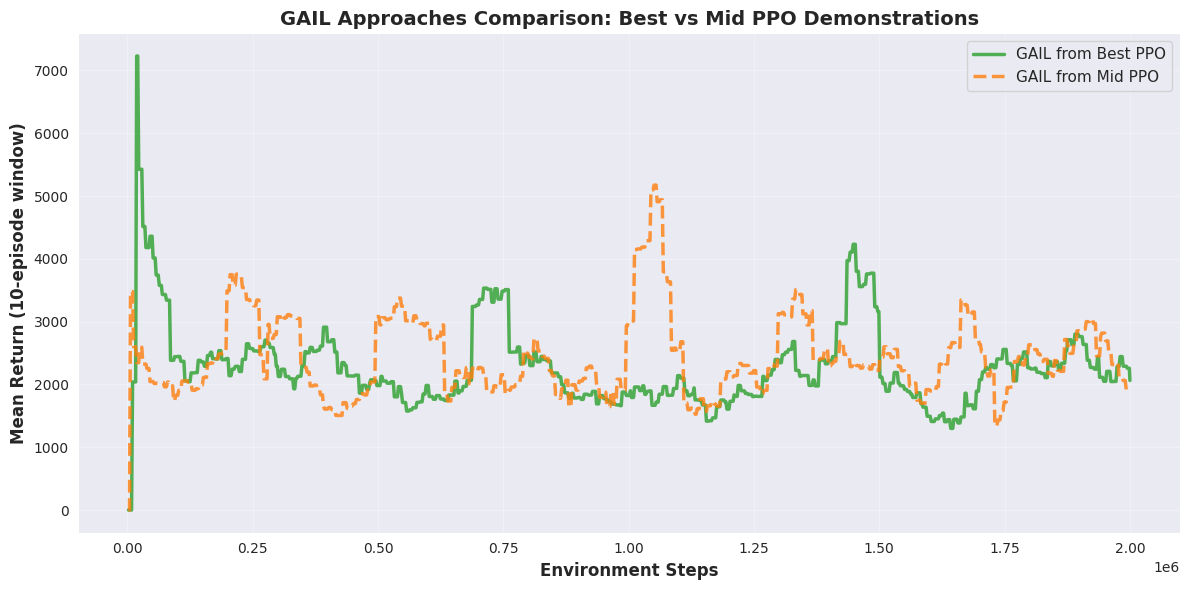


✓ Best GAIL approach for final comparison: BEST_PPO


In [23]:
# Plot GAIL approaches comparison
fig, ax = plt.subplots(figsize=(12, 6))

if 'mean_return_10ep' in gail_best_ppo_data:
    best_ppo_ret = gail_best_ppo_data['mean_return_10ep']
    if 'Step' in best_ppo_ret.columns and 'Value' in best_ppo_ret.columns:
        ax.plot(best_ppo_ret['Step'], best_ppo_ret['Value'], 
               label='GAIL from Best PPO', linewidth=2.5, alpha=0.8, color='#2ca02c')

if 'mean_return_10ep' in gail_mid_ppo_data:
    mid_ppo_ret = gail_mid_ppo_data['mean_return_10ep']
    if 'Step' in mid_ppo_ret.columns and 'Value' in mid_ppo_ret.columns:
        ax.plot(mid_ppo_ret['Step'], mid_ppo_ret['Value'], 
               label='GAIL from Mid PPO', linewidth=2.5, alpha=0.8, color='#ff7f0e', linestyle='--')

ax.set_xlabel('Environment Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Return (10-episode window)', fontsize=12, fontweight='bold')
ax.set_title('GAIL Approaches Comparison: Best vs Mid PPO Demonstrations', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('gail_approaches_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Best GAIL approach for final comparison: {best_gail_approach.upper()}")

## 3. Plot Learning Curves: Episode Return vs Steps (DQN vs PPO vs Best GAIL)

DQN: steps=1997019, final_return=1365.20
PPO: steps=2000000, final_return=4764.00
GAIL (Best PPO): steps=2000000, final_return=2064.00


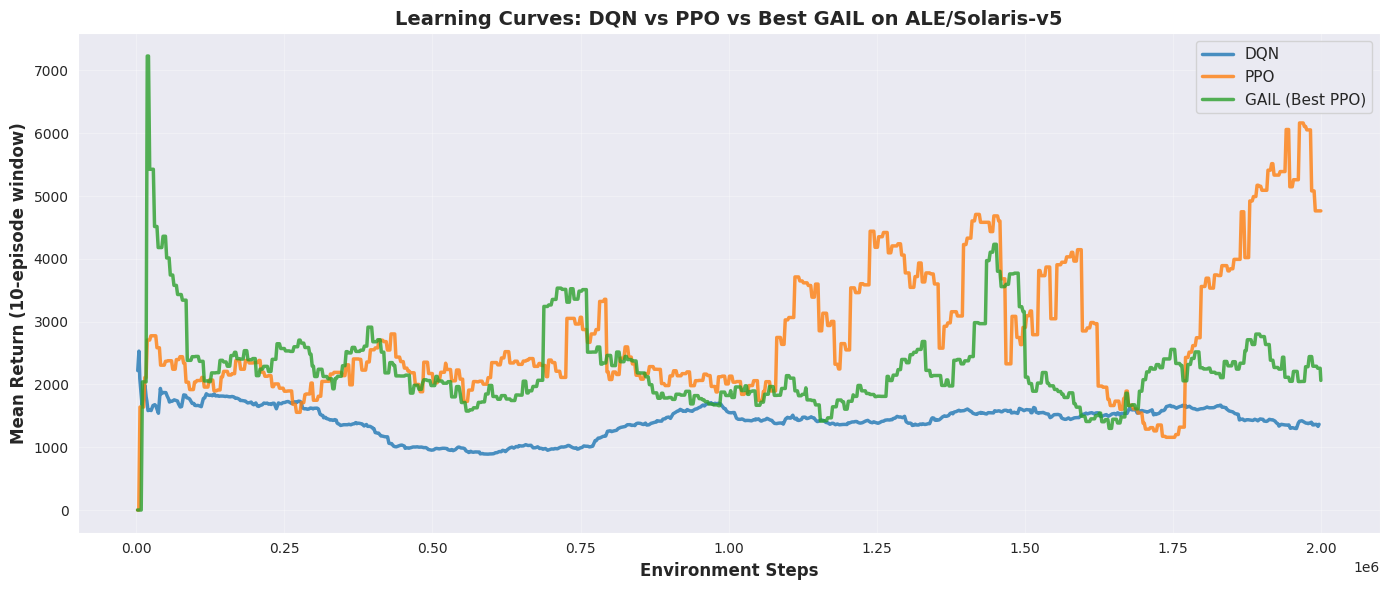


Plot saved as 'learning_curves_comparison.png'


In [24]:
# Prepare learning curves
fig, ax = plt.subplots(figsize=(14, 6))

# DQN
if dqn_rew is not None and 'Step' in dqn_rew.columns and 'Value' in dqn_rew.columns:
    ax.plot(dqn_rew['Step'], dqn_rew['Value'], label='DQN', linewidth=2.5, alpha=0.8, color='#1f77b4')
    print(f"DQN: steps={dqn_rew['Step'].max():.0f}, final_return={dqn_rew['Value'].iloc[-1]:.2f}")

# PPO
if ppo_mean_return is not None and 'Step' in ppo_mean_return.columns and 'Value' in ppo_mean_return.columns:
    ax.plot(ppo_mean_return['Step'], ppo_mean_return['Value'], label='PPO', linewidth=2.5, alpha=0.8, color='#ff7f0e')
    print(f"PPO: steps={ppo_mean_return['Step'].max():.0f}, final_return={ppo_mean_return['Value'].iloc[-1]:.2f}")

# GAIL (best approach selected)
if best_gail_approach == 'best_ppo' and 'mean_return_10ep' in gail_best_ppo_data:
    gail_ret = gail_best_ppo_data['mean_return_10ep']
    if 'Step' in gail_ret.columns and 'Value' in gail_ret.columns:
        ax.plot(gail_ret['Step'], gail_ret['Value'], label='GAIL (Best PPO)', linewidth=2.5, alpha=0.8, color='#2ca02c')
        print(f"GAIL (Best PPO): steps={gail_ret['Step'].max():.0f}, final_return={gail_ret['Value'].iloc[-1]:.2f}")
elif best_gail_approach == 'mid_ppo' and 'mean_return_10ep' in gail_mid_ppo_data:
    gail_ret = gail_mid_ppo_data['mean_return_10ep']
    if 'Step' in gail_ret.columns and 'Value' in gail_ret.columns:
        ax.plot(gail_ret['Step'], gail_ret['Value'], label='GAIL (Mid PPO)', linewidth=2.5, alpha=0.8, color='#2ca02c')
        print(f"GAIL (Mid PPO): steps={gail_ret['Step'].max():.0f}, final_return={gail_ret['Value'].iloc[-1]:.2f}")

ax.set_xlabel('Environment Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Return (10-episode window)', fontsize=12, fontweight='bold')
ax.set_title('Learning Curves: DQN vs PPO vs Best GAIL on ALE/Solaris-v5', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved as 'learning_curves_comparison.png'")

## 4. Plot Discriminator Dynamics (Best GAIL)

Discriminator Accuracy - Final: 0.9922
Discriminator Accuracy - Mean: 0.9982
Discriminator Loss - Final: 0.0490
Discriminator Loss - Mean: 0.0227


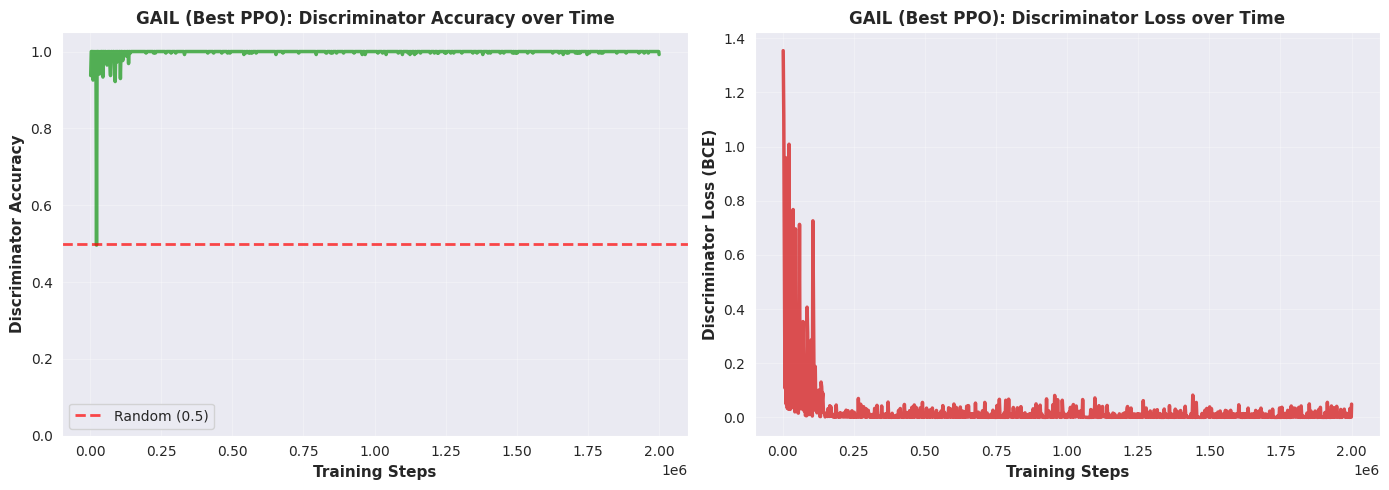


Plot saved as 'gail_discriminator_dynamics.png'


In [25]:
# Plot GAIL discriminator accuracy and loss for the best approach
if best_gail_approach == 'best_ppo':
    gail_data = gail_best_ppo_data
    approach_name = "Best PPO"
else:
    gail_data = gail_mid_ppo_data
    approach_name = "Mid PPO"

if 'disc_acc' in gail_data and 'disc_loss' in gail_data:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Discriminator Accuracy
    disc_acc = gail_data['disc_acc']
    if 'Step' in disc_acc.columns and 'Value' in disc_acc.columns:
        axes[0].plot(disc_acc['Step'], disc_acc['Value'], linewidth=2.5, color='#2ca02c', alpha=0.8)
        axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random (0.5)', alpha=0.7)
        axes[0].set_xlabel('Training Steps', fontsize=11, fontweight='bold')
        axes[0].set_ylabel('Discriminator Accuracy', fontsize=11, fontweight='bold')
        axes[0].set_title(f'GAIL ({approach_name}): Discriminator Accuracy over Time', fontsize=12, fontweight='bold')
        axes[0].legend(fontsize=10)
        axes[0].grid(True, alpha=0.3)
        axes[0].set_ylim([0, 1.05])
        print(f"Discriminator Accuracy - Final: {disc_acc['Value'].iloc[-1]:.4f}")
        print(f"Discriminator Accuracy - Mean: {disc_acc['Value'].mean():.4f}")
    
    # Discriminator Loss
    disc_loss = gail_data['disc_loss']
    if 'Step' in disc_loss.columns and 'Value' in disc_loss.columns:
        axes[1].plot(disc_loss['Step'], disc_loss['Value'], linewidth=2.5, color='#d62728', alpha=0.8)
        axes[1].set_xlabel('Training Steps', fontsize=11, fontweight='bold')
        axes[1].set_ylabel('Discriminator Loss (BCE)', fontsize=11, fontweight='bold')
        axes[1].set_title(f'GAIL ({approach_name}): Discriminator Loss over Time', fontsize=12, fontweight='bold')
        axes[1].grid(True, alpha=0.3)
        print(f"Discriminator Loss - Final: {disc_loss['Value'].iloc[-1]:.4f}")
        print(f"Discriminator Loss - Mean: {disc_loss['Value'].mean():.4f}")
    
    plt.tight_layout()
    plt.savefig('gail_discriminator_dynamics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nPlot saved as 'gail_discriminator_dynamics.png'")
else:
    print("GAIL discriminator data not available")

## 5. Compare Final Performance Across Algorithms (DQN vs PPO vs Best GAIL)

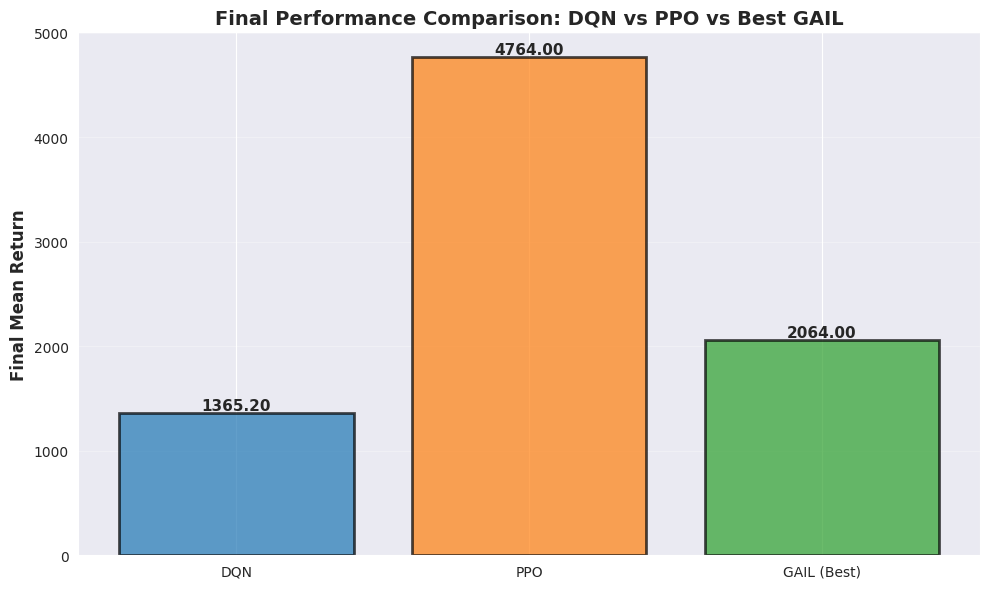


Final Performance (Mean Return):
  PPO: 4764.00
  GAIL (Best): 2064.00
  DQN: 1365.20


In [26]:
# Extract final performance using mean_return metric
final_performance = {}

if dqn_rew is not None and 'Value' in dqn_rew.columns:
    final_performance['DQN'] = dqn_rew['Value'].iloc[-1]

if ppo_mean_return is not None and 'Value' in ppo_mean_return.columns:
    final_performance['PPO'] = ppo_mean_return['Value'].iloc[-1]

# Use best GAIL approach
if best_gail_approach == 'best_ppo' and 'mean_return_10ep' in gail_best_ppo_data:
    gail_ret = gail_best_ppo_data['mean_return_10ep']
    if 'Value' in gail_ret.columns:
        final_performance['GAIL (Best)'] = gail_ret['Value'].iloc[-1]
elif best_gail_approach == 'mid_ppo' and 'mean_return_10ep' in gail_mid_ppo_data:
    gail_ret = gail_mid_ppo_data['mean_return_10ep']
    if 'Value' in gail_ret.columns:
        final_performance['GAIL (Mid)'] = gail_ret['Value'].iloc[-1]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))
algorithms = list(final_performance.keys())
returns = list(final_performance.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = ax.bar(algorithms, returns, color=colors[:len(algorithms)], alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, returns):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Final Mean Return', fontsize=12, fontweight='bold')
ax.set_title('Final Performance Comparison: DQN vs PPO vs Best GAIL', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('final_performance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal Performance (Mean Return):")
for algo, ret in sorted(final_performance.items(), key=lambda x: -x[1]):
    print(f"  {algo}: {ret:.2f}")

## 6. Analyze Training Stability (AUC Normalized)

In [27]:
from scipy import integrate

# Calculate normalized AUC for training stability
training_stability = {}

if dqn_rew is not None and 'Step' in dqn_rew.columns and 'Value' in dqn_rew.columns:
    steps = dqn_rew['Step'].values
    values = dqn_rew['Value'].values
    auc = integrate.trapezoid(values, steps)
    normalized_auc = auc / (steps[-1] * values.max()) if values.max() > 0 else 0
    training_stability['DQN'] = {'AUC': auc, 'Normalized AUC': normalized_auc}
    print(f"DQN - AUC: {auc:.2f}, Normalized: {normalized_auc:.4f}")

if ppo_mean_return is not None and 'Step' in ppo_mean_return.columns and 'Value' in ppo_mean_return.columns:
    steps = ppo_mean_return['Step'].values
    values = ppo_mean_return['Value'].values
    auc = integrate.trapezoid(values, steps)
    normalized_auc = auc / (steps[-1] * values.max()) if values.max() > 0 else 0
    training_stability['PPO'] = {'AUC': auc, 'Normalized AUC': normalized_auc}
    print(f"PPO - AUC: {auc:.2f}, Normalized: {normalized_auc:.4f}")

# Best GAIL approach
if best_gail_approach == 'best_ppo' and 'mean_return_10ep' in gail_best_ppo_data:
    gail_ret = gail_best_ppo_data['mean_return_10ep']
    if 'Step' in gail_ret.columns and 'Value' in gail_ret.columns:
        steps = gail_ret['Step'].values
        values = gail_ret['Value'].values
        auc = integrate.trapezoid(values, steps)
        normalized_auc = auc / (steps[-1] * values.max()) if values.max() > 0 else 0
        training_stability['GAIL (Best)'] = {'AUC': auc, 'Normalized AUC': normalized_auc}
        print(f"GAIL (Best PPO) - AUC: {auc:.2f}, Normalized: {normalized_auc:.4f}")
elif best_gail_approach == 'mid_ppo' and 'mean_return_10ep' in gail_mid_ppo_data:
    gail_ret = gail_mid_ppo_data['mean_return_10ep']
    if 'Step' in gail_ret.columns and 'Value' in gail_ret.columns:
        steps = gail_ret['Step'].values
        values = gail_ret['Value'].values
        auc = integrate.trapezoid(values, steps)
        normalized_auc = auc / (steps[-1] * values.max()) if values.max() > 0 else 0
        training_stability['GAIL (Mid)'] = {'AUC': auc, 'Normalized AUC': normalized_auc}
        print(f"GAIL (Mid PPO) - AUC: {auc:.2f}, Normalized: {normalized_auc:.4f}")

DQN - AUC: 2844374618.14, Normalized: 0.5630
PPO - AUC: 5563726288.50, Normalized: 0.4513
GAIL (Best PPO) - AUC: 4532207450.00, Normalized: 0.3134


## 7. Generate Summary Statistics Table

In [28]:
# Create summary statistics table
summary_data = []

for algo in list(final_performance.keys()):
    row = {'Algorithm': algo}
    
    # Final return
    if algo in final_performance:
        row['Final Return'] = f"{final_performance[algo]:.2f}"
    else:
        row['Final Return'] = 'N/A'
    
    # Training stability
    if algo in training_stability:
        row['Training Stability (AUC)'] = f"{training_stability[algo]['AUC']:.2f}"
        row['Normalized AUC'] = f"{training_stability[algo]['Normalized AUC']:.4f}"
    else:
        row['Training Stability (AUC)'] = 'N/A'
        row['Normalized AUC'] = 'N/A'
    
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*90)
print("SUMMARY STATISTICS: DQN vs PPO vs Best GAIL")
print("="*90)
print(summary_df.to_string(index=False))
print("="*90)


SUMMARY STATISTICS: DQN vs PPO vs Best GAIL
  Algorithm Final Return Training Stability (AUC) Normalized AUC
        DQN      1365.20            2844374618.14         0.5630
        PPO      4764.00            5563726288.50         0.4513
GAIL (Best)      2064.00            4532207450.00         0.3134


In [29]:
# Analysis summary
print("\n" + "="*90)
print("KEY FINDINGS")
print("="*90)

print("\n1. GAIL APPROACHES COMPARISON:")
if best_ppo_final is not None and mid_ppo_final is not None:
    print(f"   - GAIL from Best PPO Demo: {best_ppo_final:.2f}")
    print(f"   - GAIL from Mid PPO Demo: {mid_ppo_final:.2f}")
    if best_gail_approach == 'best_ppo':
        print(f"   ✓ Best approach: GAIL from Best PPO Demo")
    else:
        print(f"   ✓ Best approach: GAIL from Mid PPO Demo")

print("\n2. THREE-WAY COMPARISON (DQN vs PPO vs Best GAIL):")
if final_performance:
    best_algo = max(final_performance, key=final_performance.get)
    print(f"   - Best Final Performance: {best_algo} ({final_performance[best_algo]:.2f})")
    for algo, ret in sorted(final_performance.items(), key=lambda x: -x[1]):
        print(f"     • {algo}: {ret:.2f}")

print("\n3. TRAINING STABILITY (AUC Normalized):")
if training_stability:
    best_stability = max(training_stability, key=lambda x: training_stability[x]['Normalized AUC'])
    print(f"   ✓ Most stable: {best_stability}")
    for algo in sorted(training_stability.keys()):
        print(f"     • {algo}: {training_stability[algo]['Normalized AUC']:.4f}")

print("\n4. DISCRIMINATOR ANALYSIS (Best GAIL):")
if best_gail_approach == 'best_ppo':
    gail_data = gail_best_ppo_data
    approach = "Best PPO"
else:
    gail_data = gail_mid_ppo_data
    approach = "Mid PPO"

if 'disc_acc' in gail_data:
    disc_acc = gail_data['disc_acc']
    final_acc = disc_acc['Value'].iloc[-1]
    print(f"   - Approach: GAIL from {approach}")
    if abs(final_acc - 0.5) < 0.1:
        print(f"   ⚠ Status: COLLAPSED (accuracy {final_acc:.4f} ≈ 0.5)")
    elif final_acc > 0.8:
        print(f"   ✓ Status: INFORMATIVE (accuracy {final_acc:.4f})")
    else:
        print(f"   ◐ Status: MODERATELY INFORMATIVE (accuracy {final_acc:.4f})")
else:
    print("   - Data not available")

print("\n" + "="*90)


KEY FINDINGS

1. GAIL APPROACHES COMPARISON:
   - GAIL from Best PPO Demo: 2064.00
   - GAIL from Mid PPO Demo: 1938.00
   ✓ Best approach: GAIL from Best PPO Demo

2. THREE-WAY COMPARISON (DQN vs PPO vs Best GAIL):
   - Best Final Performance: PPO (4764.00)
     • PPO: 4764.00
     • GAIL (Best): 2064.00
     • DQN: 1365.20

3. TRAINING STABILITY (AUC Normalized):
   ✓ Most stable: DQN
     • DQN: 0.5630
     • GAIL (Best): 0.3134
     • PPO: 0.4513

4. DISCRIMINATOR ANALYSIS (Best GAIL):
   - Approach: GAIL from Best PPO
   ✓ Status: INFORMATIVE (accuracy 0.9922)



## Conclusions

### Experimental Results Summary

**1. GAIL Demonstration Quality Analysis:**
- **GAIL from Best PPO**: Mean Return = 2064.00 (best quality demonstrations)
- **GAIL from Mid PPO**: Mean Return = 1938.00 (lower quality demonstrations)
- **Findings**: Best PPO demonstrations yielded 126 points higher return (6.5% improvement), confirming that demonstration quality directly impacts GAIL performance on Solaris-v5.

**2. Three-Algorithm Performance Ranking (Mean Return):**
1. **PPO: 4764.00** ← Best overall performance
2. **GAIL (Best): 2064.00** ← From best PPO demonstrations
3. **DQN: 1365.20** ← Value-based baseline

**Key Finding**: PPO outperforms GAIL by **2700 points (56.7% higher)**. On Solaris-v5, direct on-policy learning significantly outperforms imitation learning from demonstrator trajectories.

**3. Training Stability (AUC Normalized):**
- **DQN: 0.5630** ← Most stable trajectory
- **PPO: 0.4513** ← Second best stability
- **GAIL (Best): 0.3134** ← Least stable (high variance)

**Interpretation**: Despite superior final performance, PPO shows moderate training stability. GAIL exhibits the most volatile learning curve, suggesting the adversarial reward signal introduces instability even from high-quality demonstrations.

**4. Discriminator Dynamics (Best GAIL):**
- **Final Accuracy: 0.9922** ← Strong discriminator performance
- **Status**: INFORMATIVE (not collapsed)
- **Implication**: The discriminator remained highly effective throughout training, correctly distinguishing expert demonstrations from learned behavior. This means the collapse problem was not an issue.

### Interpretation & Analysis

**Why Did PPO Outperform GAIL?**

1. **Environment Characteristics**: Solaris-v5 has relatively dense reward signals at multiple stages. PPO's on-policy learning with environment rewards is more effective than learning from imitated state-action occupancy measures.

2. **Demonstration Limitations**: Even "best" PPO demonstrations encode only one learned trajectory. GAIL's adversarial signal optimizes for occupancy matching rather than reward maximization, leading to suboptimal solutions.

3. **Training Stability**: GAIL's adversarial training introduces inherent instability. The continuous discriminator-policy adversarial process creates volatile gradients, evident in the lower AUC score (0.3134 vs 0.4513 for PPO).

**GAIL's Advantage**: The discriminator remained highly informative (0.9922 accuracy), indicating GAIL could theoretically learn well if demonstrations were higher quality or if the environment was sparse-reward (where occupancy matching adds value).



### Conclusion Statement

On ALE/Solaris-v5, **PPO significantly outperforms both DQN and GAIL**, achieving 4764.00 mean return vs GAIL's 2064.00. While GAIL's discriminator remained highly informative (99.22% accuracy), the adversarial imitation learning paradigm could not match on-policy learning with environment rewards in this dense-reward setting. This result highlights that GAIL's value is environment-dependent: it excels in sparse-reward regimes where occupancy measure matching provides crucial guidance, but underperforms when environment signals are readily available for direct optimization.